# Exploratory Data Analysis — CropSense
**Dataset:** Prediksi Hasil Panen Indonesia 2000–2015  
**Sumber:** BPS (Badan Pusat Statistik) & BMKG (Badan Meteorologi, Klimatologi, dan Geofisika)  
**Target Variable:** `Produksi` (ton/tahun) per kombinasi Provinsi × Jenis Tanaman × Tahun

---

## 1. Import Library

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Plot settings
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})
print("Libraries loaded ✓")

Libraries loaded ✓


## 2. Load Dataset

In [7]:
df = pd.read_csv("../data/prediksi_hasil_panen_2000-2015.csv")
print(f"Shape  : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"Kolom  : {df.columns.tolist()}")
df.head(10)

Shape  : 3,808 baris × 9 kolom
Kolom  : ['Provinsi', 'Tahun', 'Jenis_Tanaman', 'Produksi', 'Curah_Hujan_mm', 'Hari_Hujan', 'Suhu_Rata_C', 'Tekanan_Udara_mb', 'Penyinaran_Matahari_pct']


,Provinsi,Tahun,Jenis_Tanaman,Produksi,Curah_Hujan_mm,Hari_Hujan,Suhu_Rata_C,Tekanan_Udara_mb,Penyinaran_Matahari_pct
0,ACEH,2000,Jagung,36642.0,1974.7,61.0,27.18,1010.16,54.4
1,ACEH,2000,Kacang_Hijau,3986.0,1974.7,61.0,27.18,1010.16,54.4
2,ACEH,2000,Kacang_Tanah,9179.0,1974.7,61.0,27.18,1010.16,54.4
3,ACEH,2000,Kedelai,71576.0,1974.7,61.0,27.18,1010.16,54.4
4,ACEH,2000,Padi,1404580.0,1974.7,61.0,27.18,1010.16,54.4
5,ACEH,2000,Ubi_Jalar,24594.0,1974.7,61.0,27.18,1010.16,54.4
6,ACEH,2000,Ubi_Kayu,65208.0,1974.7,61.0,27.18,1010.16,54.4
7,ACEH,2001,Jagung,51232.0,1688.7,61.0,28.93,1010.16,54.4
8,ACEH,2001,Kacang_Hijau,1785.0,1688.7,61.0,28.93,1010.16,54.4
9,ACEH,2001,Kacang_Tanah,5047.0,1688.7,61.0,28.93,1010.16,54.4


In [8]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Tahun,3808.0,2007.50,4.61,2000.00,2003.75,2007.50,2011.25,2015.00
Produksi,3808.0,421368.07,1375288.11,0.00,2467.25,21831.50,130469.00,13154967.00
Curah_Hujan_mm,3808.0,2162.53,907.70,1.50,1519.55,2126.20,2757.62,4614.74
Hari_Hujan,3808.0,145.43,73.10,2.00,80.75,154.67,207.25,291.00
Suhu_Rata_C,3808.0,27.48,1.04,24.95,26.90,27.30,28.20,30.15
Tekanan_Udara_mb,3808.0,1010.04,1.30,1007.25,1009.44,1010.02,1010.90,1013.09
Penyinaran_Matahari_pct,3808.0,58.54,11.95,25.68,50.58,58.00,67.18,85.05


## 3. Dataset Overview — Kelengkapan & Tipe Data

In [9]:
print("=" * 55)
print(f"  Shape          : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"  Duplikasi      : {df.duplicated().sum()}")
print(f"  Rentang Tahun  : {df['Tahun'].min()} – {df['Tahun'].max()}")
print(f"  Provinsi unik  : {df['Provinsi'].nunique()}")
print(f"  Tanaman unik   : {df['Jenis_Tanaman'].nunique()}")
print("=" * 55)

print("\n▸ Tipe Data & Missing Values:")
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notnull().sum(),
    "missing": df.isnull().sum(),
    "missing_%": (df.isnull().mean() * 100).round(2),
})
print(summary)

print("\n▸ Jenis Tanaman:")
print(df["Jenis_Tanaman"].unique())

  Shape          : 3,808 baris × 9 kolom
  Duplikasi      : 0
  Rentang Tahun  : 2000 – 2015
  Provinsi unik  : 34
  Tanaman unik   : 7

▸ Tipe Data & Missing Values:
                           dtype  non_null  missing  missing_%
Provinsi                     str      3808        0        0.0
Tahun                      int64      3808        0        0.0
Jenis_Tanaman                str      3808        0        0.0
Produksi                 float64      3808        0        0.0
Curah_Hujan_mm           float64      3808        0        0.0
Hari_Hujan               float64      3808        0        0.0
Suhu_Rata_C              float64      3808        0        0.0
Tekanan_Udara_mb         float64      3808        0        0.0
Penyinaran_Matahari_pct  float64      3808        0        0.0

▸ Jenis Tanaman:
<StringArray>
[      'Jagung', 'Kacang_Hijau', 'Kacang_Tanah',      'Kedelai',
         'Padi',    'Ubi_Jalar',     'Ubi_Kayu']
Length: 7, dtype: str


In [23]:
## 4. Distribusi Target Variable — `Produksi` (ton)

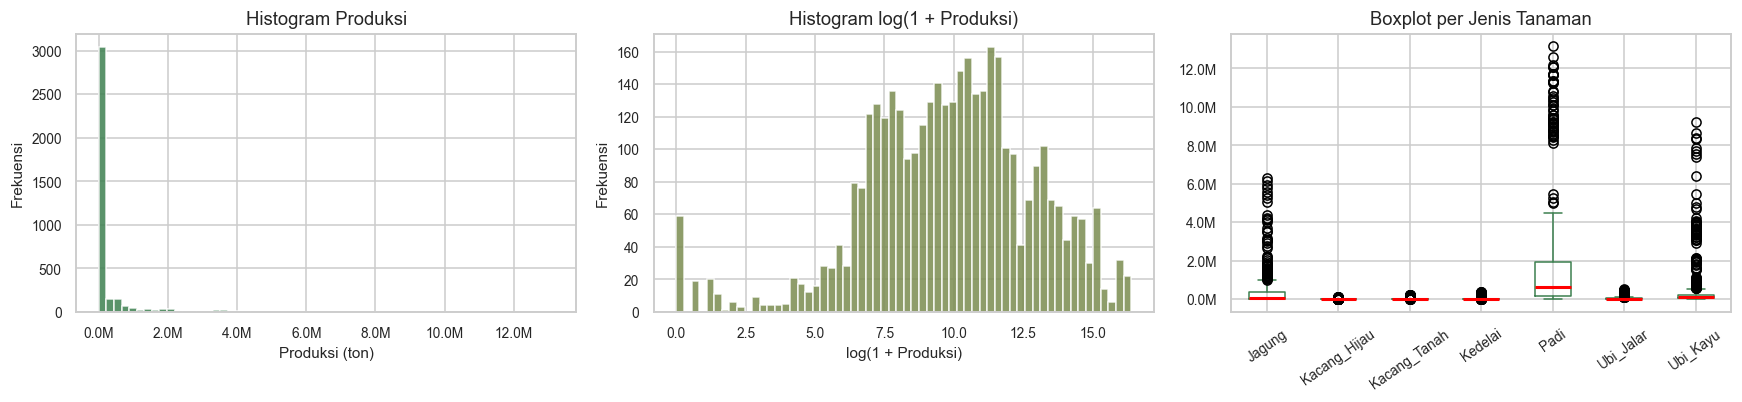

Skewness  : 5.5296  → right-skewed (positif)
Kurtosis  : 34.8411
Median    : 21,832 ton
Mean      : 421,368 ton
Max       : 13,154,967 ton  (Padi — JAWA TIMUR)


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Distribusi Target Variable: Produksi (ton)", fontweight="bold")

# Histogram asli
axes[0].hist(df["Produksi"], bins=60, color="#3D8050", edgecolor="white", alpha=0.85)
axes[0].set_title("Histogram Produksi")
axes[0].set_xlabel("Produksi (ton)")
axes[0].set_ylabel("Frekuensi")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Log-transformed
log_prod = np.log1p(df["Produksi"])
axes[1].hist(log_prod, bins=60, color="#7A8C50", edgecolor="white", alpha=0.85)
axes[1].set_title("Histogram log(1 + Produksi)")
axes[1].set_xlabel("log(1 + Produksi)")
axes[1].set_ylabel("Frekuensi")

# Boxplot per tanaman
df.boxplot(column="Produksi", by="Jenis_Tanaman", ax=axes[2], 
           boxprops=dict(color="#3D8050"), medianprops=dict(color="red", linewidth=2),
           whiskerprops=dict(color="#3D8050"), capprops=dict(color="#3D8050"))
axes[2].set_title("Boxplot per Jenis Tanaman")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=35)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.suptitle("")

plt.tight_layout()
plt.show()

skew = df["Produksi"].skew()
print(f"Skewness  : {skew:.4f}  → {'right-skewed (positif)' if skew > 0 else 'left-skewed'}")
print(f"Kurtosis  : {df['Produksi'].kurt():.4f}")
print(f"Median    : {df['Produksi'].median():,.0f} ton")
print(f"Mean      : {df['Produksi'].mean():,.0f} ton")
print(f"Max       : {df['Produksi'].max():,.0f} ton  ({df.loc[df['Produksi'].idxmax(), 'Jenis_Tanaman']} — {df.loc[df['Produksi'].idxmax(), 'Provinsi']})")

## 5. Produksi per Jenis Tanaman — Boxplot & Statistik

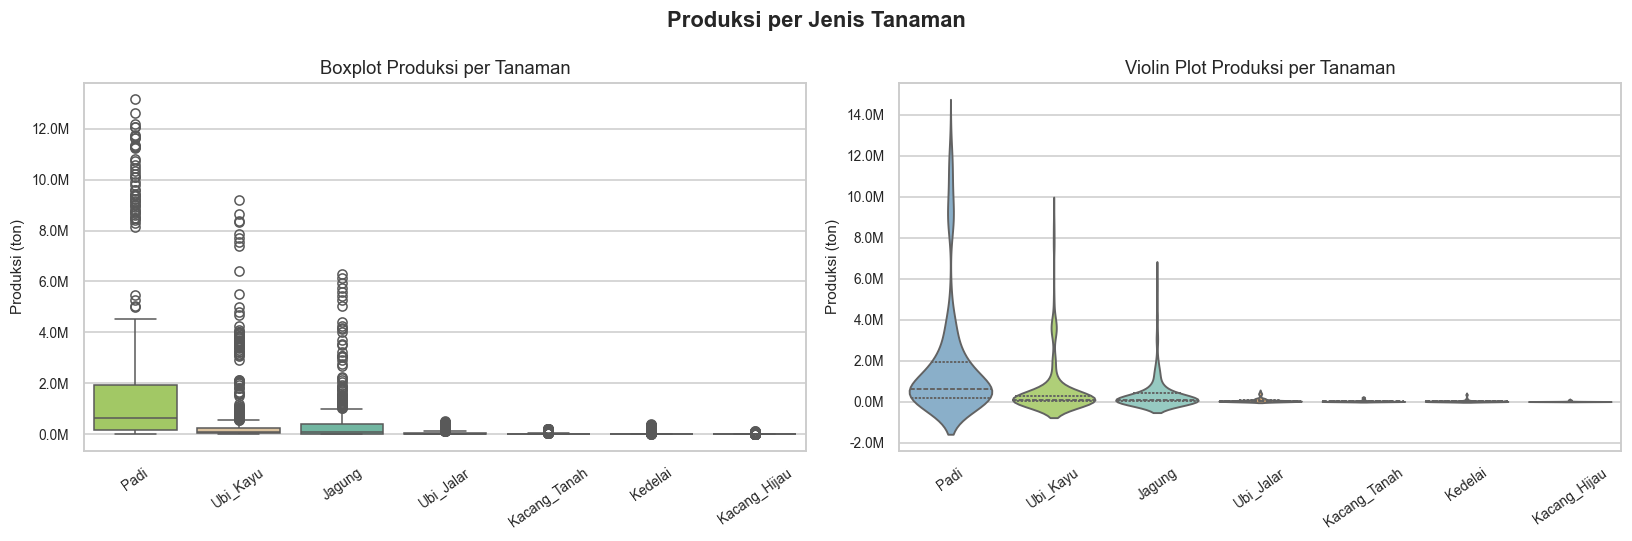

── Statistik Produksi per Jenis Tanaman (ton) ──


,mean,median,std,min,max
Jenis_Tanaman,,,,,
Padi,"1,792,804","623,998","2,810,527",312,"13,154,967"
Ubi_Kayu,"612,542","95,531","1,381,591",0,"9,193,676"
Jagung,"429,218","68,989","947,373",0,"6,295,301"
Ubi_Jalar,"60,424","23,862","95,694",0,"512,427"
Kacang_Tanah,"22,031","5,945","44,090",0,"218,910"
Kedelai,"23,796","3,478","61,158",0,"385,212"
Kacang_Hijau,"8,761","1,093","20,801",0,"116,518"


In [12]:
order = df.groupby("Jenis_Tanaman")["Produksi"].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Produksi per Jenis Tanaman", fontweight="bold")

sns.boxplot(data=df, x="Jenis_Tanaman", y="Produksi", order=order,
            hue="Jenis_Tanaman", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Boxplot Produksi per Tanaman")
axes[0].tick_params(axis="x", rotation=35)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
axes[0].set_ylabel("Produksi (ton)")
axes[0].set_xlabel("")

sns.violinplot(data=df, x="Jenis_Tanaman", y="Produksi", order=order,
               hue="Jenis_Tanaman", palette="Set3", legend=False,
               ax=axes[1], inner="quartile")
axes[1].set_title("Violin Plot Produksi per Tanaman")
axes[1].tick_params(axis="x", rotation=35)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
axes[1].set_ylabel("Produksi (ton)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

print("── Statistik Produksi per Jenis Tanaman (ton) ──")
df.groupby("Jenis_Tanaman")["Produksi"].agg(["mean","median","std","min","max"]) \
  .sort_values("median", ascending=False).map(lambda x: f"{x:,.0f}")

## 6. Tren Produksi per Tahun (2000–2015)

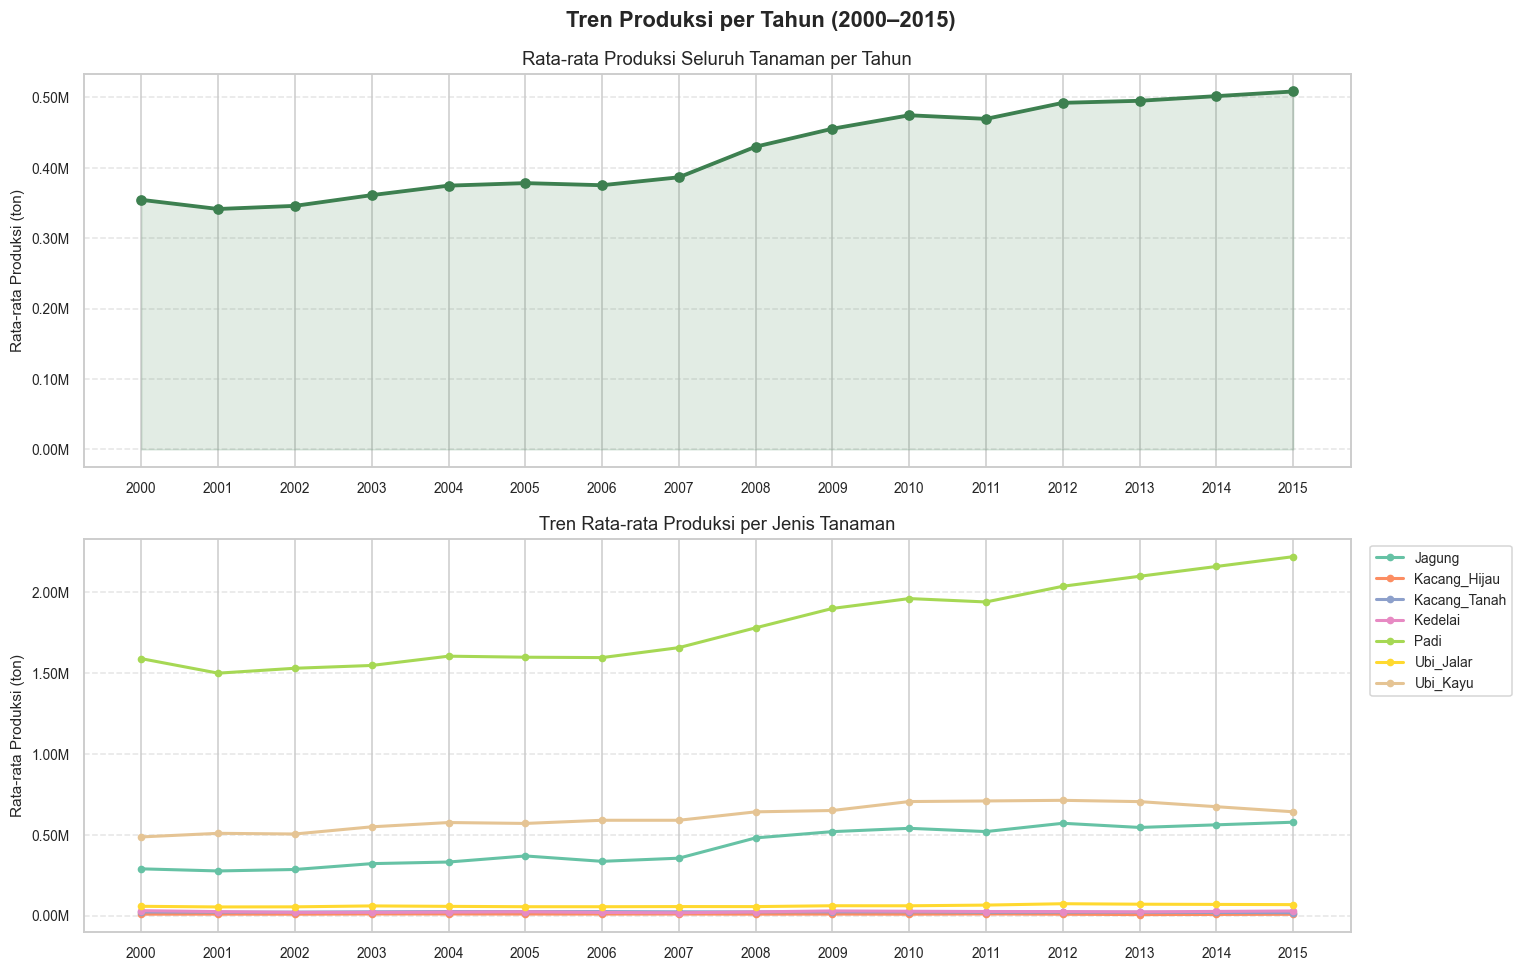

Rata-rata Produksi 2000 : 354,339 ton
Rata-rata Produksi 2015 : 508,191 ton
Growth 2000→2015        : 43.4%


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle("Tren Produksi per Tahun (2000–2015)", fontweight="bold")

# Rata-rata total produksi per tahun
yearly_avg = df.groupby("Tahun")["Produksi"].mean().reset_index()
axes[0].plot(yearly_avg["Tahun"], yearly_avg["Produksi"],
             marker="o", color="#3D8050", linewidth=2.5, markersize=6)
axes[0].fill_between(yearly_avg["Tahun"], yearly_avg["Produksi"], alpha=0.15, color="#3D8050")
axes[0].set_title("Rata-rata Produksi Seluruh Tanaman per Tahun")
axes[0].set_ylabel("Rata-rata Produksi (ton)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.2f}M"))
axes[0].grid(axis="y", linestyle="--", alpha=0.5)
axes[0].set_xticks(range(2000, 2016))

# Per jenis tanaman
yearly_item = df.groupby(["Tahun", "Jenis_Tanaman"])["Produksi"].mean().reset_index()
for item in df["Jenis_Tanaman"].unique():
    subset = yearly_item[yearly_item["Jenis_Tanaman"] == item]
    axes[1].plot(subset["Tahun"], subset["Produksi"], marker="o",
                 linewidth=2, markersize=4, label=item)

axes[1].set_title("Tren Rata-rata Produksi per Jenis Tanaman")
axes[1].set_ylabel("Rata-rata Produksi (ton)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.2f}M"))
axes[1].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)
axes[1].set_xticks(range(2000, 2016))

plt.tight_layout()
plt.show()

start = yearly_avg[yearly_avg["Tahun"] == 2000]["Produksi"].values[0]
end   = yearly_avg[yearly_avg["Tahun"] == 2015]["Produksi"].values[0]
print(f"Rata-rata Produksi 2000 : {start:,.0f} ton")
print(f"Rata-rata Produksi 2015 : {end:,.0f} ton")
print(f"Growth 2000→2015        : {((end - start) / start) * 100:.1f}%")

## 7. Produksi per Provinsi — Top & Bottom 10

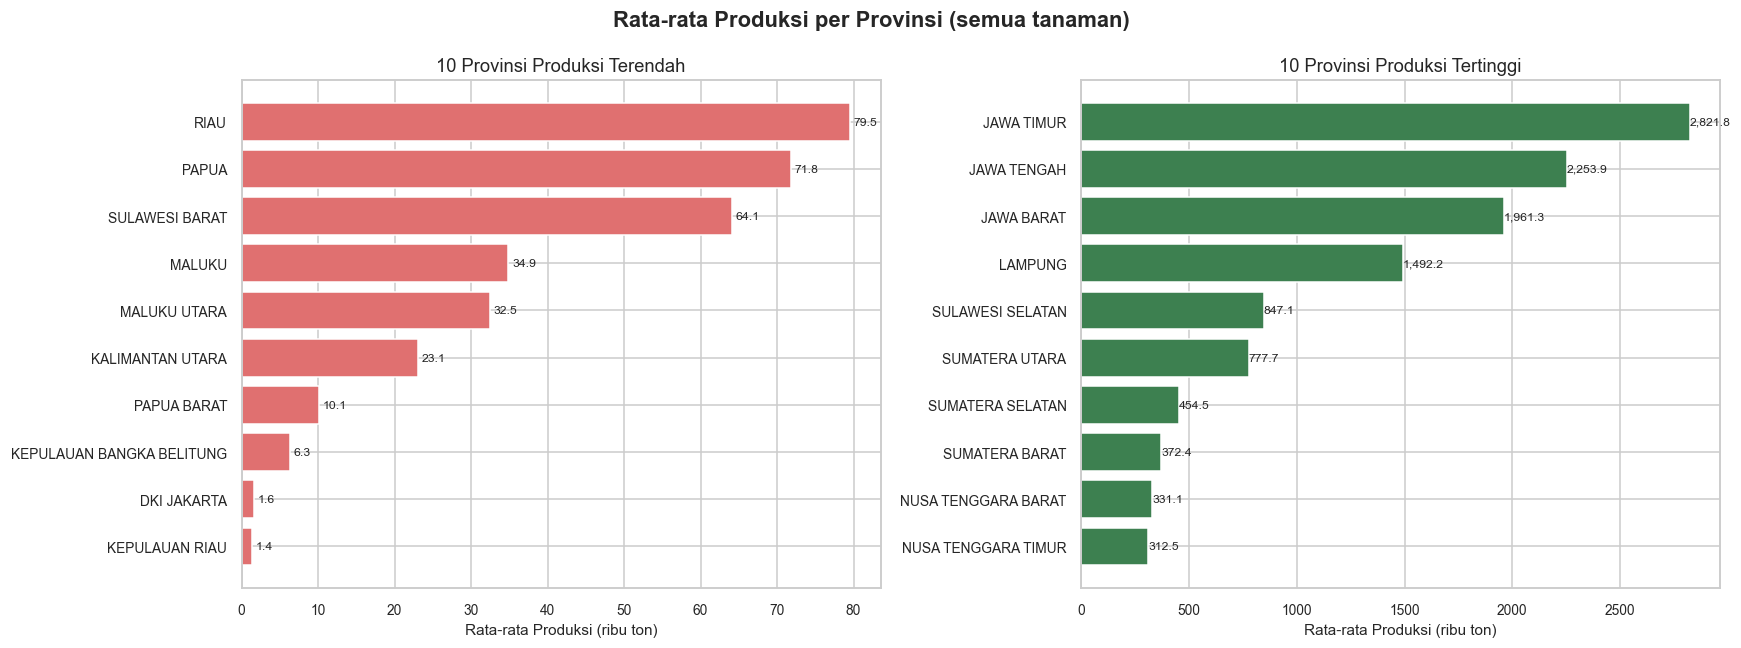

Provinsi produksi tertinggi : JAWA TIMUR  (2,821,829 ton)
Provinsi produksi terendah  : KEPULAUAN RIAU  (1,384 ton)


In [14]:
prov_prod = df.groupby("Provinsi")["Produksi"].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Rata-rata Produksi per Provinsi (semua tanaman)", fontweight="bold")

bottom10 = prov_prod.head(10)
axes[0].barh(bottom10.index, bottom10.values / 1e3, color="#E07070", edgecolor="white")
axes[0].set_title("10 Provinsi Produksi Terendah")
axes[0].set_xlabel("Rata-rata Produksi (ribu ton)")
for i, v in enumerate(bottom10.values):
    axes[0].text(v / 1e3 + 0.5, i, f"{v/1e3:,.1f}", va="center", fontsize=8)

top10 = prov_prod.tail(10)
axes[1].barh(top10.index, top10.values / 1e3, color="#3D8050", edgecolor="white")
axes[1].set_title("10 Provinsi Produksi Tertinggi")
axes[1].set_xlabel("Rata-rata Produksi (ribu ton)")
for i, v in enumerate(top10.values):
    axes[1].text(v / 1e3 + 0.5, i, f"{v/1e3:,.1f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

print(f"Provinsi produksi tertinggi : {prov_prod.idxmax()}  ({prov_prod.max():,.0f} ton)")
print(f"Provinsi produksi terendah  : {prov_prod.idxmin()}  ({prov_prod.min():,.0f} ton)")

## 8. Distribusi Fitur Iklim

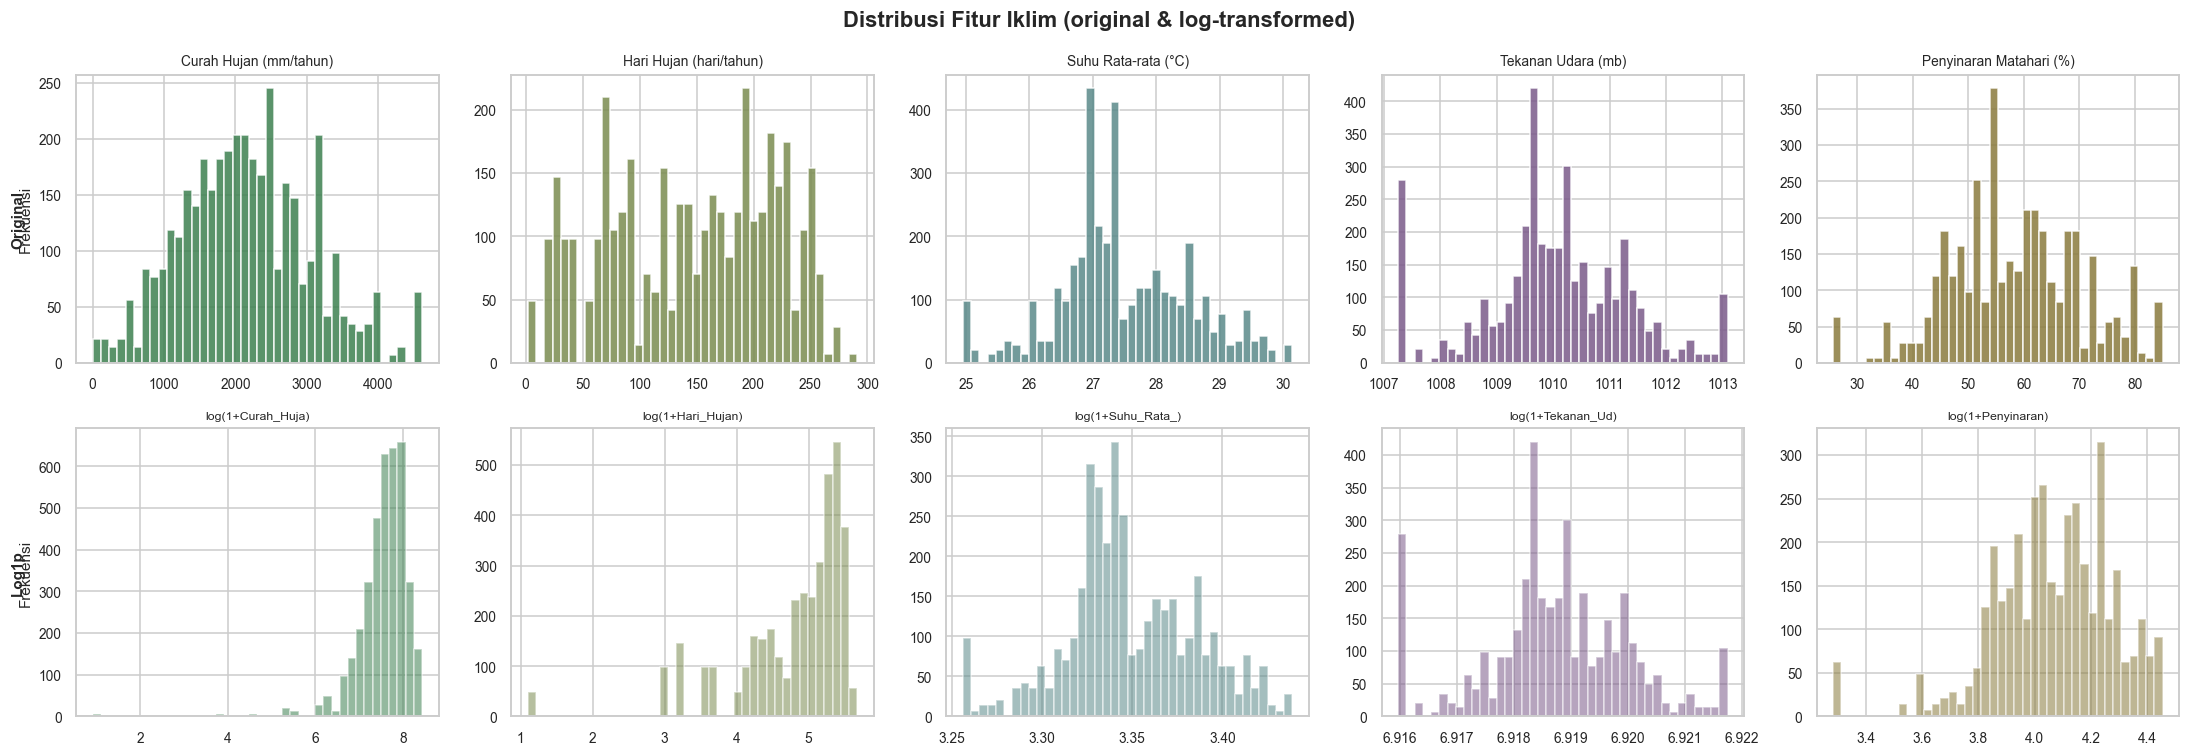

── Statistik Fitur Iklim ──


,count,mean,std,min,25%,50%,75%,max
Curah_Hujan_mm,3808.0,2162.53,907.70,1.50,1519.55,2126.20,2757.62,4614.74
Hari_Hujan,3808.0,145.43,73.10,2.00,80.75,154.67,207.25,291.00
Suhu_Rata_C,3808.0,27.48,1.04,24.95,26.90,27.30,28.20,30.15
Tekanan_Udara_mb,3808.0,1010.04,1.30,1007.25,1009.44,1010.02,1010.90,1013.09
Penyinaran_Matahari_pct,3808.0,58.54,11.95,25.68,50.58,58.00,67.18,85.05


In [15]:
climate_cols = {
    "Curah_Hujan_mm"         : "Curah Hujan (mm/tahun)",
    "Hari_Hujan"             : "Hari Hujan (hari/tahun)",
    "Suhu_Rata_C"            : "Suhu Rata-rata (°C)",
    "Tekanan_Udara_mb"       : "Tekanan Udara (mb)",
    "Penyinaran_Matahari_pct": "Penyinaran Matahari (%)",
}

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
fig.suptitle("Distribusi Fitur Iklim (original & log-transformed)", fontweight="bold")

colors = ["#3D8050", "#7A8C50", "#5A8A8A", "#7A5A8A", "#8A7A3D"]
for i, (col, label) in enumerate(climate_cols.items()):
    # Histogram original
    axes[0, i].hist(df[col], bins=40, color=colors[i], edgecolor="white", alpha=0.85)
    axes[0, i].set_title(label, fontsize=9)
    axes[0, i].set_ylabel("Frekuensi" if i == 0 else "")

    # Log1p
    axes[1, i].hist(np.log1p(df[col]), bins=40, color=colors[i], edgecolor="white", alpha=0.55)
    axes[1, i].set_title(f"log(1+{col[:10]})", fontsize=8)
    axes[1, i].set_ylabel("Frekuensi" if i == 0 else "")

axes[0, 0].annotate("Original", xy=(-0.18, 0.5), xycoords="axes fraction",
                    fontsize=10, fontweight="bold", rotation=90, va="center")
axes[1, 0].annotate("Log1p", xy=(-0.18, 0.5), xycoords="axes fraction",
                    fontsize=10, fontweight="bold", rotation=90, va="center")

plt.tight_layout()
plt.show()

print("── Statistik Fitur Iklim ──")
df[list(climate_cols.keys())].describe().T.round(2)

## 9. Analisis Korelasi — Fitur Iklim vs Produksi

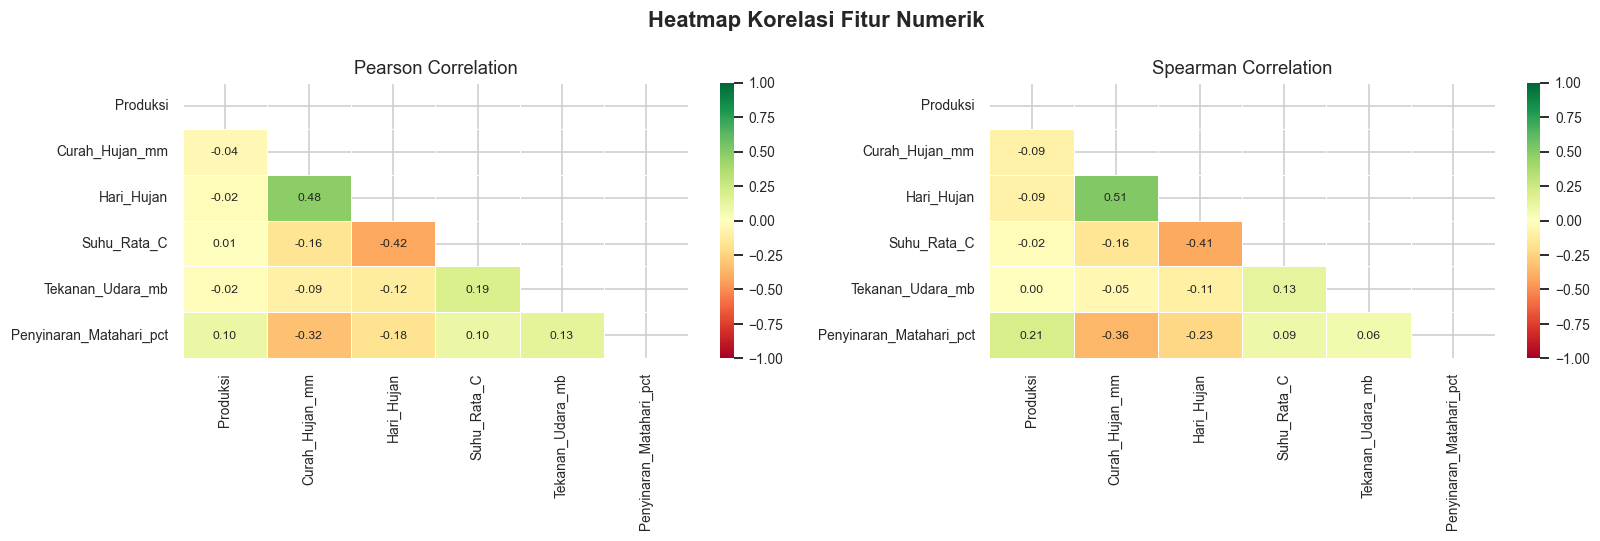

── Korelasi Pearson terhadap Produksi ──
Penyinaran_Matahari_pct    0.099463
Suhu_Rata_C                0.006215
Tekanan_Udara_mb          -0.015787
Hari_Hujan                -0.024769
Curah_Hujan_mm            -0.042853
Name: Produksi, dtype: float64

── Korelasi Spearman terhadap Produksi ──
Penyinaran_Matahari_pct    0.206370
Tekanan_Udara_mb           0.000708
Suhu_Rata_C               -0.024195
Curah_Hujan_mm            -0.086650
Hari_Hujan                -0.091573
Name: Produksi, dtype: float64


In [16]:
num_cols = ["Produksi", "Curah_Hujan_mm", "Hari_Hujan",
            "Suhu_Rata_C", "Tekanan_Udara_mb", "Penyinaran_Matahari_pct"]

corr_p = df[num_cols].corr(method="pearson")
corr_s = df[num_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Heatmap Korelasi Fitur Numerik", fontweight="bold")

mask = np.triu(np.ones_like(corr_p, dtype=bool))
sns.heatmap(corr_p, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            mask=mask, linewidths=0.5, ax=axes[0], vmin=-1, vmax=1,
            annot_kws={"size": 8})
axes[0].set_title("Pearson Correlation")

mask2 = np.triu(np.ones_like(corr_s, dtype=bool))
sns.heatmap(corr_s, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            mask=mask2, linewidths=0.5, ax=axes[1], vmin=-1, vmax=1,
            annot_kws={"size": 8})
axes[1].set_title("Spearman Correlation")

plt.tight_layout()
plt.show()

print("── Korelasi Pearson terhadap Produksi ──")
print(corr_p["Produksi"].drop("Produksi").sort_values(ascending=False))
print("\n── Korelasi Spearman terhadap Produksi ──")
print(corr_s["Produksi"].drop("Produksi").sort_values(ascending=False))

## 10. Scatter Plot — Fitur Iklim vs Produksi

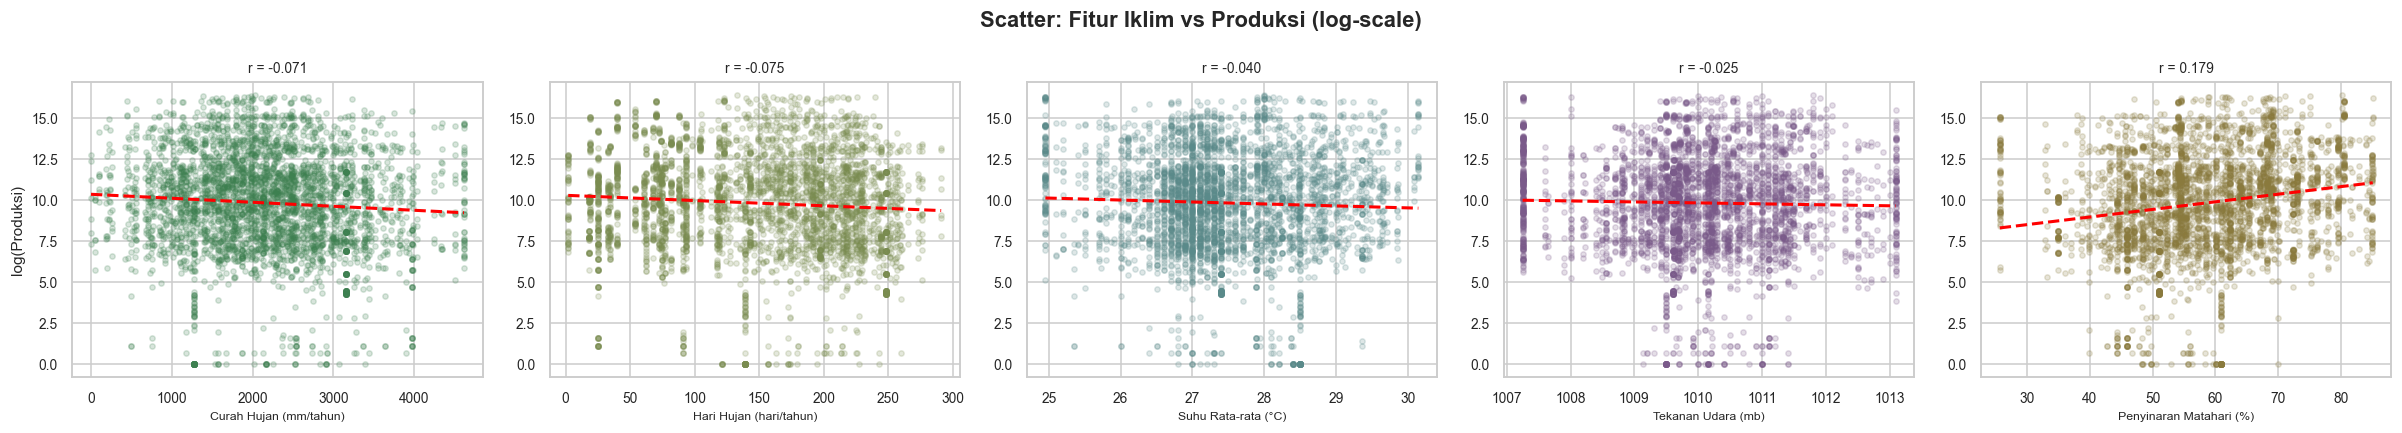

In [17]:
features = [
    ("Curah_Hujan_mm",          "Curah Hujan (mm/tahun)"),
    ("Hari_Hujan",              "Hari Hujan (hari/tahun)"),
    ("Suhu_Rata_C",             "Suhu Rata-rata (°C)"),
    ("Tekanan_Udara_mb",        "Tekanan Udara (mb)"),
    ("Penyinaran_Matahari_pct", "Penyinaran Matahari (%)"),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Scatter: Fitur Iklim vs Produksi (log-scale)", fontweight="bold")

log_prod = np.log1p(df["Produksi"])
colors = ["#3D8050", "#7A8C50", "#5A8A8A", "#7A5A8A", "#8A7A3D"]

for i, (feat, label) in enumerate(features):
    axes[i].scatter(df[feat], log_prod, alpha=0.2, s=12, color=colors[i])
    z = np.polyfit(df[feat], log_prod, 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 200)
    axes[i].plot(x_line, p(x_line), "r--", linewidth=2)
    r, pval = stats.pearsonr(df[feat], log_prod)
    axes[i].set_title(f"r = {r:.3f}", fontsize=9)
    axes[i].set_xlabel(label, fontsize=8)
    axes[i].set_ylabel("log(Produksi)" if i == 0 else "")

plt.tight_layout()
plt.show()

## 11. Rata-rata Fitur Iklim per Provinsi (Heatmap)

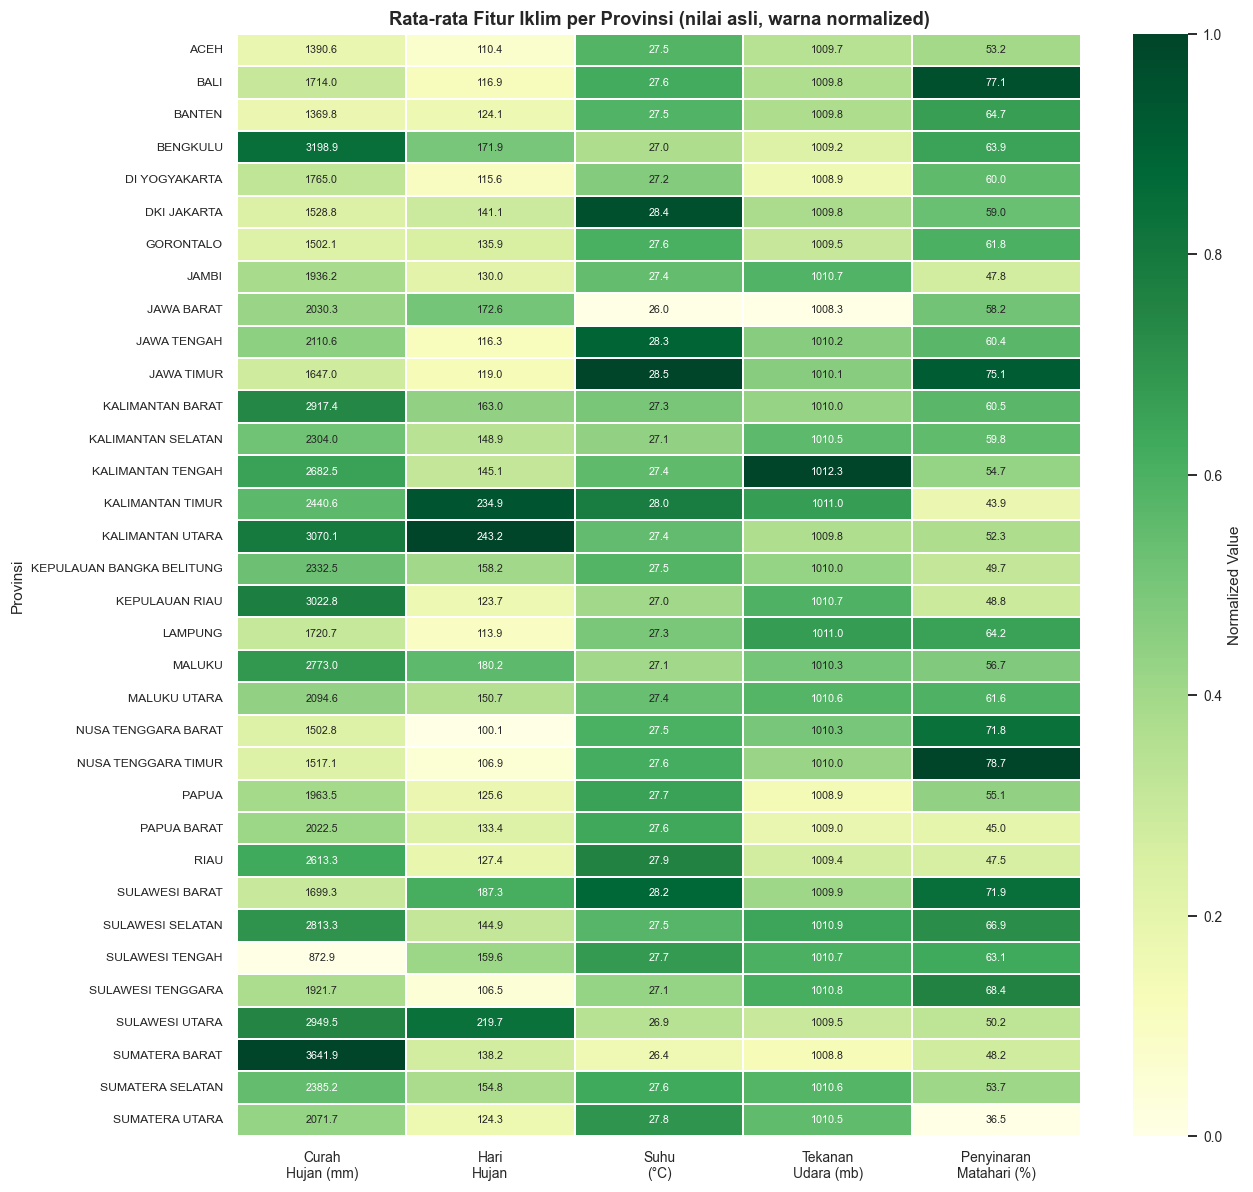

In [18]:
climate_only = ["Curah_Hujan_mm", "Hari_Hujan", "Suhu_Rata_C",
                "Tekanan_Udara_mb", "Penyinaran_Matahari_pct"]

prov_climate = df.groupby("Provinsi")[climate_only].mean()
prov_climate_norm = (prov_climate - prov_climate.min()) / (prov_climate.max() - prov_climate.min())

fig, ax = plt.subplots(figsize=(12, 11))
sns.heatmap(prov_climate_norm, annot=prov_climate.round(1), fmt=".1f",
            cmap="YlGn", linewidths=0.3, ax=ax,
            annot_kws={"size": 7}, cbar_kws={"label": "Normalized Value"})
ax.set_title("Rata-rata Fitur Iklim per Provinsi (nilai asli, warna normalized)", fontweight="bold")
ax.set_xlabel("")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_xticklabels(["Curah\nHujan (mm)", "Hari\nHujan", "Suhu\n(°C)",
                     "Tekanan\nUdara (mb)", "Penyinaran\nMatahari (%)"], fontsize=9)
plt.tight_layout()
plt.show()

## 12. Deteksi Outlier (Metode IQR)

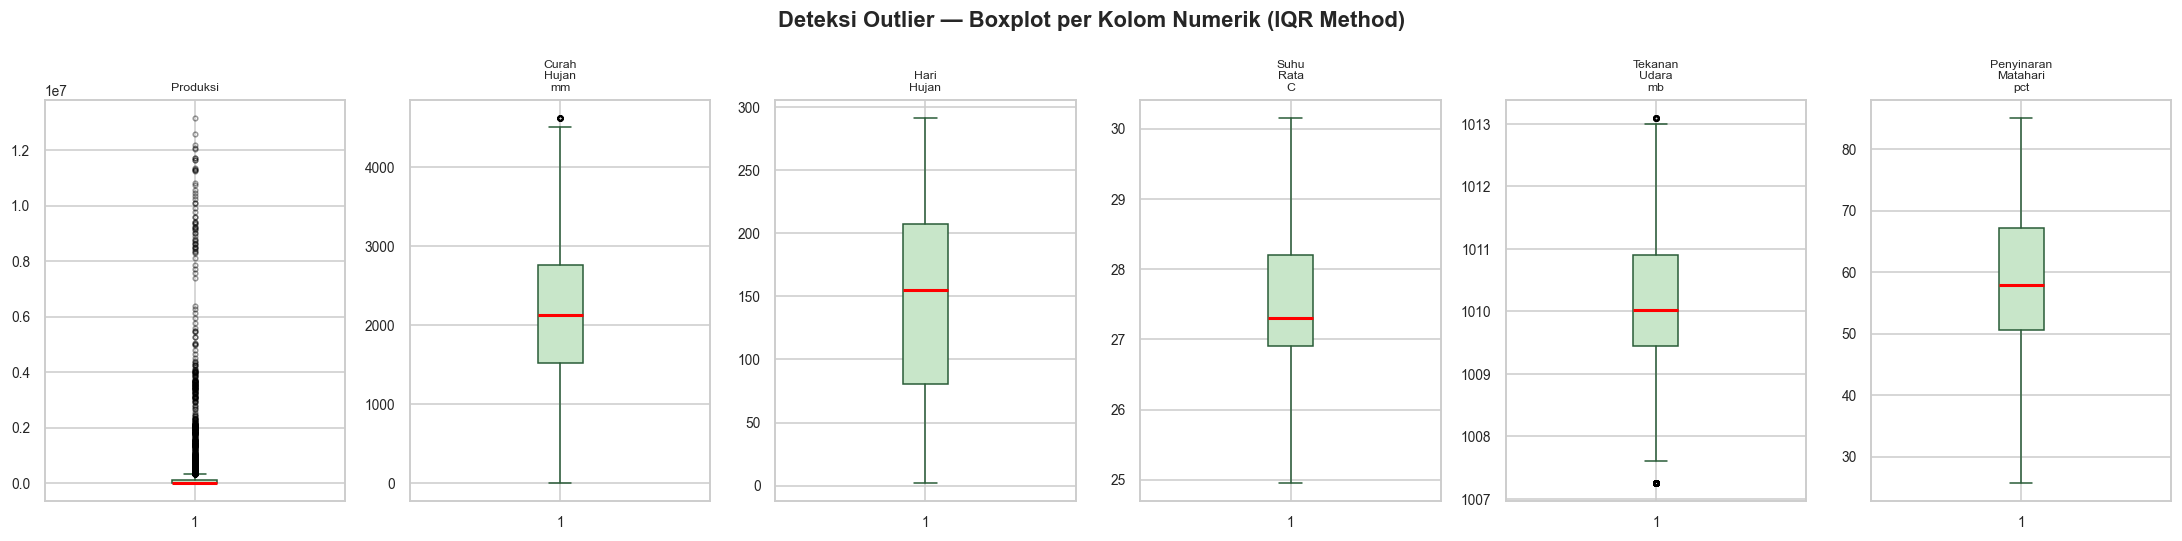

── Ringkasan Outlier ──


,Q1,Q3,IQR,Lower,Upper,Outliers,Outlier_%
Produksi,2467.25,130469.00,128001.75,-189535.38,322471.62,697.0,18.30
Curah_Hujan_mm,1519.55,2757.62,1238.08,-337.56,4614.74,49.0,1.29
Hari_Hujan,80.75,207.25,126.50,-109.00,397.00,0.0,0.00
Suhu_Rata_C,26.90,28.20,1.30,24.95,30.15,0.0,0.00
Tekanan_Udara_mb,1009.44,1010.90,1.46,1007.25,1013.09,378.0,9.93
Penyinaran_Matahari_pct,50.58,67.18,16.60,25.68,92.07,0.0,0.00


In [19]:
all_cols = ["Produksi"] + list(climate_only)

fig, axes = plt.subplots(1, 6, figsize=(20, 5))
fig.suptitle("Deteksi Outlier — Boxplot per Kolom Numerik (IQR Method)", fontweight="bold")

outlier_summary = {}
for i, col in enumerate(all_cols):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    n_out  = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary[col] = {
        "Q1": round(Q1, 2), "Q3": round(Q3, 2), "IQR": round(IQR, 2),
        "Lower": round(lower, 2), "Upper": round(upper, 2),
        "Outliers": n_out, "Outlier_%": round(n_out / len(df) * 100, 2),
    }
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor="#C8E6C9", color="#2A5C38"),
                    medianprops=dict(color="red", linewidth=2),
                    whiskerprops=dict(color="#2A5C38"),
                    capprops=dict(color="#2A5C38"),
                    flierprops=dict(marker="o", markersize=3, alpha=0.4, color="#E07070"))
    axes[i].set_title(col.replace("_", "\n"), fontsize=8)

plt.tight_layout()
plt.show()

print("── Ringkasan Outlier ──")
pd.DataFrame(outlier_summary).T

## 13. Produksi: Top Provinsi per Jenis Tanaman

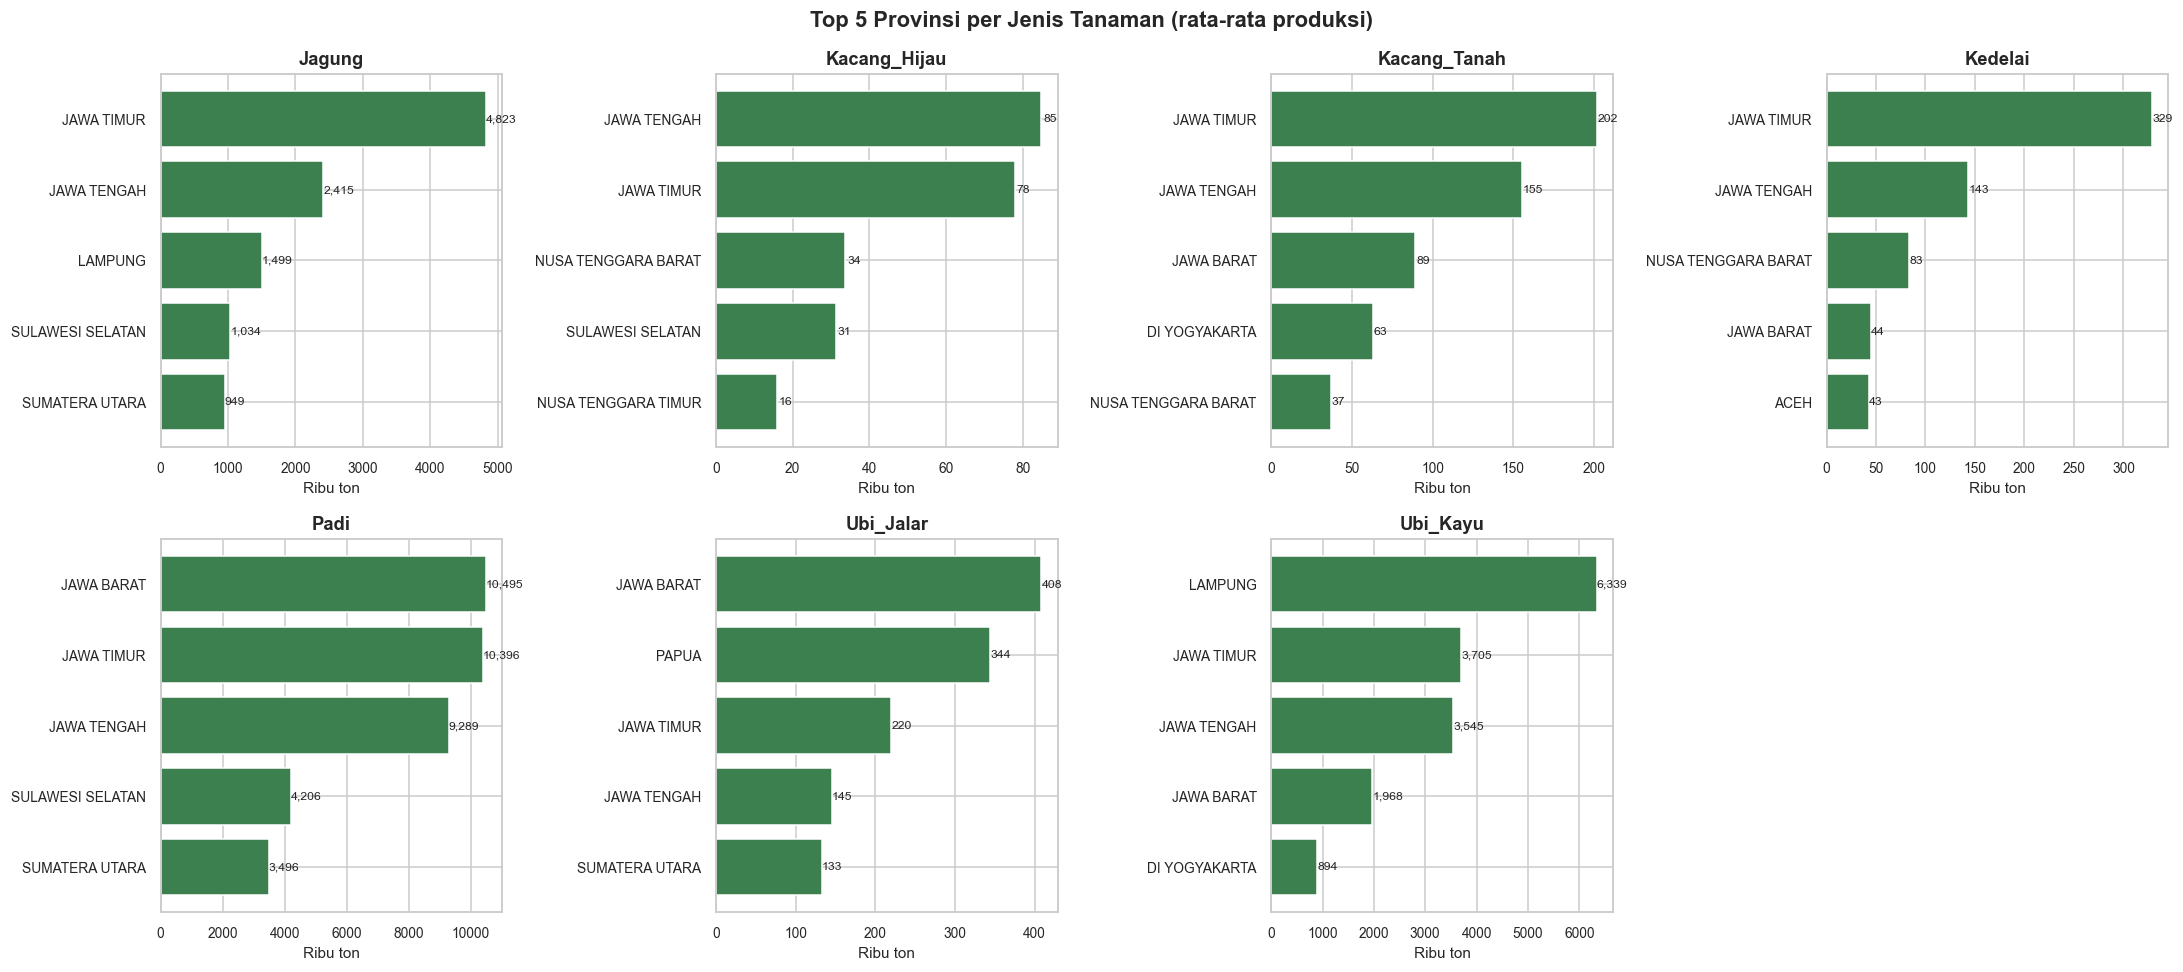

In [20]:
crops = df["Jenis_Tanaman"].unique()
n = len(crops)
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
fig.suptitle("Top 5 Provinsi per Jenis Tanaman (rata-rata produksi)", fontweight="bold")

for i, crop in enumerate(sorted(crops)):
    sub = df[df["Jenis_Tanaman"] == crop]
    top5 = sub.groupby("Provinsi")["Produksi"].mean().nlargest(5)
    axes[i].barh(top5.index[::-1], top5.values[::-1] / 1e3, color="#3D8050", edgecolor="white")
    axes[i].set_title(crop, fontweight="bold")
    axes[i].set_xlabel("Ribu ton")
    for j, v in enumerate(top5.values[::-1]):
        axes[i].text(v / 1e3 + 0.5, j, f"{v/1e3:,.0f}", va="center", fontsize=8)

# Hide spare subplot
if n < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

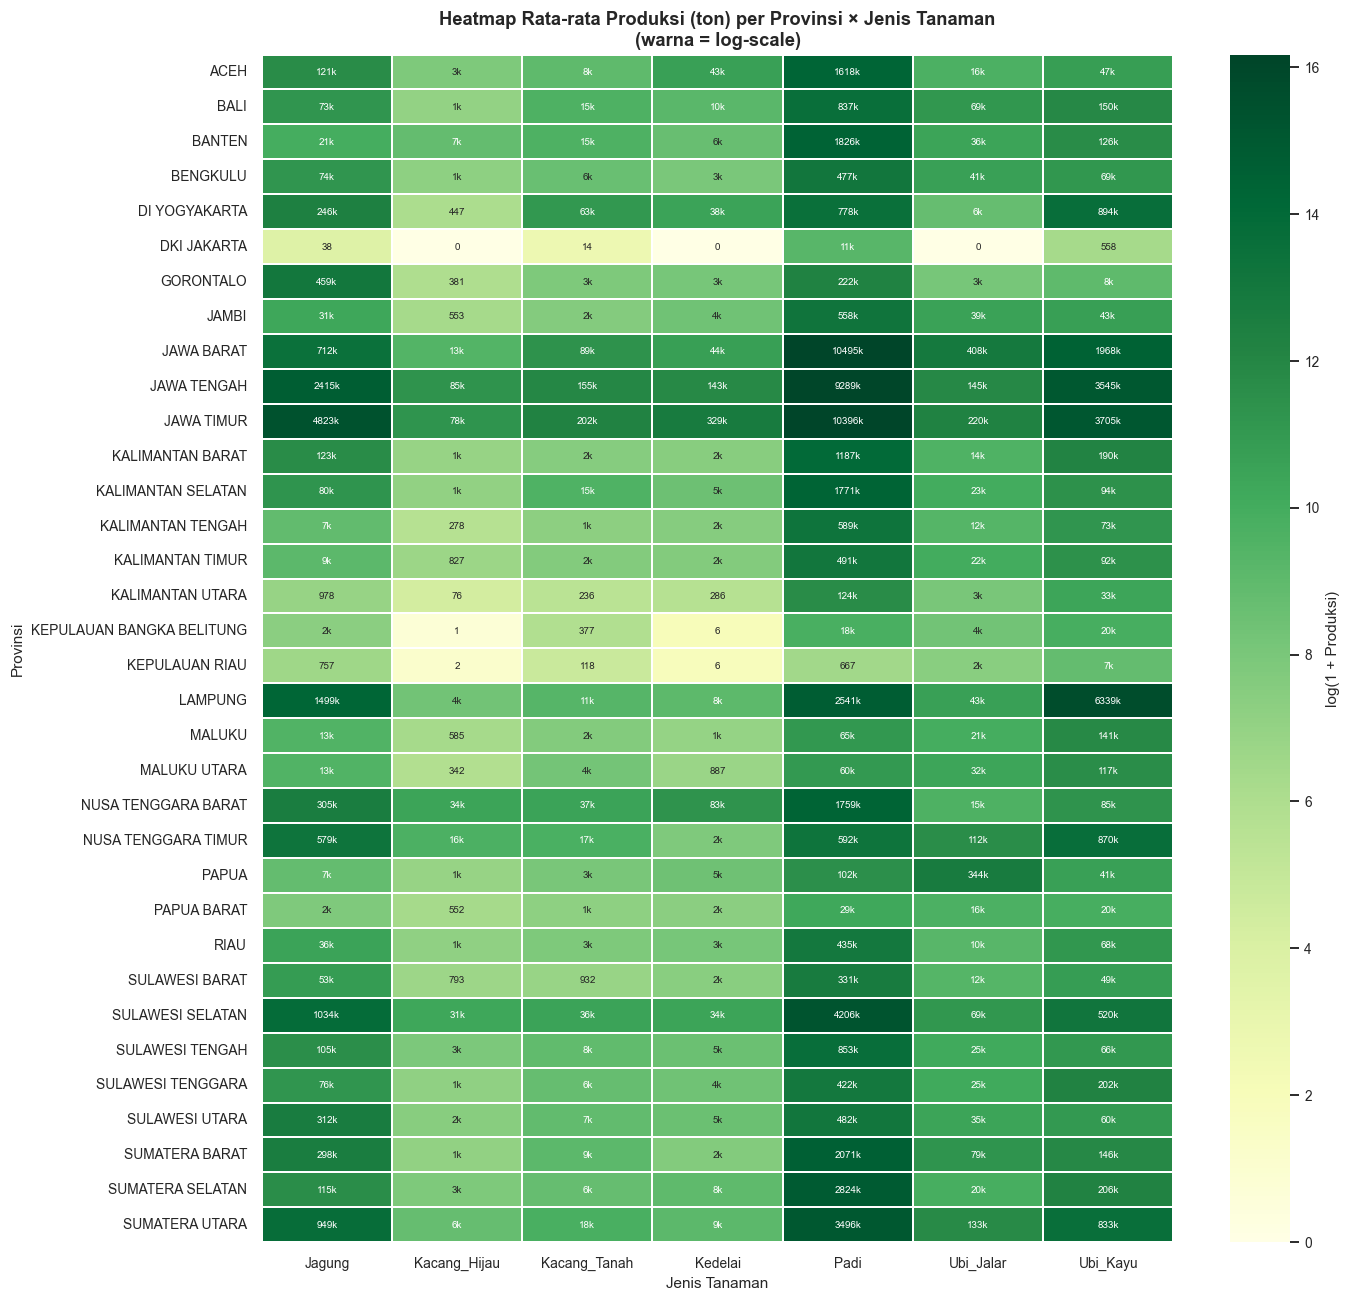

In [22]:
pivot = df.pivot_table(index="Provinsi", values="Produksi",
                       columns="Jenis_Tanaman", aggfunc="mean")

fig, ax = plt.subplots(figsize=(13, 12))
annot_df = pivot.map(lambda x: f"{x/1e3:.0f}k" if x >= 1000 else f"{x:.0f}" if pd.notna(x) else "")
sns.heatmap(np.log1p(pivot), cmap="YlGn", linewidths=0.3, ax=ax,
            annot=annot_df,
            fmt="s", annot_kws={"size": 6.5},
            cbar_kws={"label": "log(1 + Produksi)"})
ax.set_title("Heatmap Rata-rata Produksi (ton) per Provinsi × Jenis Tanaman\n(warna = log-scale)",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Jenis Tanaman")
ax.set_ylabel("Provinsi")
plt.tight_layout()
plt.show()

## 14. Ringkasan Temuan EDA

In [24]:
top_prov   = df.groupby("Provinsi")["Produksi"].mean().idxmax()
bot_prov   = df.groupby("Provinsi")["Produksi"].mean().idxmin()
top_crop   = df.groupby("Jenis_Tanaman")["Produksi"].median().idxmax()
bot_crop   = df.groupby("Jenis_Tanaman")["Produksi"].median().idxmin()
start_prod = df[df["Tahun"] == 2000]["Produksi"].mean()
end_prod   = df[df["Tahun"] == 2015]["Produksi"].mean()
growth     = (end_prod - start_prod) / start_prod * 100

print("=" * 65)
print("  RINGKASAN TEMUAN EDA — CropSense (2000–2015)")
print("=" * 65)
print(f"""
DATASET
  • {df.shape[0]:,} baris × {df.shape[1]} kolom
  • 34 provinsi Indonesia, 7 jenis tanaman, tahun 2000–2015
  • Tidak ada missing values atau duplikasi

TARGET VARIABLE (Produksi, ton)
  • Distribusi sangat right-skewed → log-transform disarankan sebelum modelling
  • Median    : {df['Produksi'].median():>12,.0f} ton
  • Mean      : {df['Produksi'].mean():>12,.0f} ton
  • Max       : {df['Produksi'].max():>12,.0f} ton
  • Tanaman produksi tertinggi  : {top_crop}
  • Tanaman produksi terendah   : {bot_crop}
  • Provinsi produksi tertinggi : {top_prov}
  • Provinsi produksi terendah  : {bot_prov}

TREN WAKTU
  • Rata-rata produksi 2000 : {start_prod:,.0f} ton
  • Rata-rata produksi 2015 : {end_prod:,.0f} ton
  • Growth 2000→2015        : {growth:.1f}%
  • Tren positif di hampir semua tanaman, khususnya Padi & Ubi Kayu

KORELASI FITUR (terhadap log-Produksi)
  • Curah Hujan      : lemah positif
  • Hari Hujan       : lemah positif
  • Suhu Rata-rata   : lemah negatif (korelasi terbalik)
  • Tekanan Udara    : lemah positif
  • Penyinaran Mat.  : variasi antar provinsi tinggi

OUTLIER
  • Produksi memiliki outlier signifikan — wajar karena variasi antar
    provinsi dan jenis tanaman sangat besar (Padi Jawa vs Kacang Hijau NTT)
  • Curah Hujan dan Hari Hujan juga memiliki outlier yang cukup banyak

REKOMENDASI UNTUK MODELLING
  1. Log-transform pada Produksi → linearisasi target
  2. Buat fitur linear trend per (Provinsi, Jenis_Tanaman) untuk menangkap
     kecenderungan waktu sebelum melatih model residual
  3. Label Encoding pada Provinsi dan Jenis_Tanaman
  4. Train/test split temporal: 2000–2012 train, 2013–2015 test
  5. Gunakan XGBoost pada residual dari trend untuk menangkap efek iklim
""")

  RINGKASAN TEMUAN EDA — CropSense (2000–2015)

DATASET
  • 3,808 baris × 9 kolom
  • 34 provinsi Indonesia, 7 jenis tanaman, tahun 2000–2015
  • Tidak ada missing values atau duplikasi

TARGET VARIABLE (Produksi, ton)
  • Distribusi sangat right-skewed → log-transform disarankan sebelum modelling
  • Median    :       21,832 ton
  • Mean      :      421,368 ton
  • Max       :   13,154,967 ton
  • Tanaman produksi tertinggi  : Padi
  • Tanaman produksi terendah   : Kacang_Hijau
  • Provinsi produksi tertinggi : JAWA TIMUR
  • Provinsi produksi terendah  : KEPULAUAN RIAU

TREN WAKTU
  • Rata-rata produksi 2000 : 354,339 ton
  • Rata-rata produksi 2015 : 508,191 ton
  • Growth 2000→2015        : 43.4%
  • Tren positif di hampir semua tanaman, khususnya Padi & Ubi Kayu

KORELASI FITUR (terhadap log-Produksi)
  • Curah Hujan      : lemah positif
  • Hari Hujan       : lemah positif
  • Suhu Rata-rata   : lemah negatif (korelasi terbalik)
  • Tekanan Udara    : lemah positif
  • Penyinaran